## Model 2: Unpooled NTA Neighborhood Differences

In this notebook, we will be answering the question,

"On an average summer day in New York City, how does the intensity of noise complaints vary by reason, neighborhood, and weekday—relative to citywide patterns—and how confident are we in those differences?"

To answer this question we will be using only NTA data, we will be comparing output stats of raw data to the result geneated from a baysian model. 

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="pkg_resources is deprecated as an API",
    category=UserWarning,
)

In [2]:
import pymc as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import arviz as az
from helpers import ( prep_the_data, 
                      export_geo_kepler, 
                      build_typical_week_city_relative_ratio,
                      make_daily_table_for_model_with_nta,
                      make_topn_table,
                      plot_puma_model_vs_observed,
                      export_idata,
                      summarize_lam_posterior
                    )

import geopandas as gpd
from keplergl import KeplerGl

### Load + prepare data: 2021-2024 

In [3]:
out_path = "../data/processed/kepler"

In [4]:
df_puma = pd.read_parquet(
    "../data/processed/features/puma_noise_counts.parquet"
)


In [5]:
df_puma = prep_the_data(df_puma)

In [6]:
df_puma_2021__2024 = df_puma.loc[
    (df_puma["created_bucket"] >= "2021-01-01") &
    (df_puma["created_bucket"] <  "2024-12-31")
].copy()


In [7]:
df_puma_2021__2024.head()

,puma,complaint_type,descriptor,location_type,created_bucket,time_of_day,complaint_count,nta,area_share_of_puma,nta_name,nta_puma,dow,month,is_weekend,month_year,descriptor_group,dow_complaint
0,4103,Noise,Noise,NR5,2022-06-09,day,1,MN0303,0.403905,East Village,East Village — 4103,Thursday,June,0,June__2022,Other,OTHER__Thursday
1,4103,Noise,"Noise, Barking Dog",NaN,2021-07-10,night,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,July,1,July__2021,Animal,ANIMAL__Saturday
2,4103,Noise,"Noise, Barking Dog",NaN,2021-08-07,day,1,MN0303,0.403905,East Village,East Village — 4103,Saturday,August,1,August__2021,Animal,ANIMAL__Saturday
3,4103,Noise,"Noise, Barking Dog",NaN,2021-08-13,day,1,MN0303,0.403905,East Village,East Village — 4103,Friday,August,0,August__2021,Animal,ANIMAL__Friday
4,4103,Noise,"Noise, Barking Dog",NaN,2021-08-15,night,2,MN0303,0.403905,East Village,East Village — 4103,Sunday,August,1,August__2021,Animal,ANIMAL__Sunday


### During a typical week in the summer of New York, where are the most Noise Complaints


We are going to compute the average complaint rate for the entire city on each weekday, then express each neighborhood’s rate 
as a ratio relative to that baseline. This helps us see which areas are unusually noisy rather than just busy 
on high-volume days.

#### We begin this analysis using the raw data to answer this question.

In [8]:
city_rel_ratio_raw = build_typical_week_city_relative_ratio(
    df_puma_2021__2024,
    puma_col="nta_name",
    nta_puma_col=None,
    agg="median",
).rename(columns={"puma": "nta"})

In [9]:
city_rel_ratio_raw.head()

,nta,complaint,dow,typical_daily_count,city_weekday_mean,city_relative_ratio,date
0,Annadale-Huguenot-Prince's Bay-Woodrow,Animal,Friday,1.0,1.027273,0.973451,2000-01-07
1,Annadale-Huguenot-Prince's Bay-Woodrow,Animal,Monday,1.0,1.009091,0.990991,2000-01-03
2,Annadale-Huguenot-Prince's Bay-Woodrow,Animal,Saturday,1.0,1.000000,1.000000,2000-01-08
3,Annadale-Huguenot-Prince's Bay-Woodrow,Animal,Sunday,1.0,1.009091,0.990991,2000-01-09
4,Annadale-Huguenot-Prince's Bay-Woodrow,Animal,Thursday,1.0,1.018182,0.982143,2000-01-06


In [10]:
gdf_rel = export_geo_kepler(
    city_rel_ratio_raw,
    geojson_path="../data/raw/nyc/geographies/nyc_ntas_2020.geojson",
    df_key="nta",
    geo_key="NTAName",
    value_cols=["city_relative_ratio"],
    fill_value=0.0,
    out_path=f"{out_path}/02_01_raw_nta_typical_week_city_relative_intensity_2021__2024.geojson",
)

#### Next we will use a Baysean Model to see if we can improve our answer

In [11]:
daily_df, coords = make_daily_table_for_model_with_nta(
    df_puma_2021__2024,
    complaint_col="descriptor_group",
)

In [12]:
# -----------------------------
# Data for the model
# -----------------------------
y = daily_df["daily_count"].to_numpy(dtype=int)
nta_idx = daily_df["nta_idx"].to_numpy(dtype=int)
dow_idx = daily_df["dow_idx"].to_numpy(dtype=int)


We use a Bayesian model to describe how we think complaint counts are generated, then update that belief once we see the actual data.
We begin by constructing our **prior**. Because we’re modeling counts (how many complaints happen in a day), a Poisson distribution is a natural choice. 
It’s the standard model for events that happen independently over time or space.
For each (NTA, weekday) pair, we assume there’s some underlying average complaint rate, called λ (lambda). We don’t know this rate ahead of time, 
but we do know it has to be positive, so we place an Exponential prior on it. This keeps the rate in a realistic range and gently discourages 
extreme values unless the data strongly supports them. The **likelihood** is simply the bridge between the model and the data — it tells us how well a 
particular rate would explain the counts we actually observed. After combining our prior assumptions with the observed data, we get the **posterior**, 
which is our updated, data-informed estimate of the complaint rates.

To simplify:
  - Prior → what we believe
  - Likelihood → what we observed
  - Posterior → updated belief after combining both

In [13]:

with pm.Model(coords=coords) as model_pois:

    # Expected daily complaints per (NTA, weekday)
    lam = pm.Exponential("lam", 1.0, dims=("nta", "dow"))

    # Likelihood
    y_obs = pm.Poisson("y_obs", mu=lam[nta_idx, dow_idx], observed=y)

    # Sampling
    idata_nta_pois = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
        idata_kwargs={"log_likelihood": True},
    )



Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.


This table is a summary of the results from the Bayesian model. It helps us check two things:

**Did the sampler converge properly?**

**What rates did the model learn for each (NTA, weekday)?**

First, look at the sampling diagnostics:

**ess_bulk** and **ess_tail** should be large → this means we effectively have lots of independent samples

**r_hat** should be very close to 1.0 → this tells us the chains mixed well and converged

If these look good, we can trust the estimates.

Next, look at the parameter estimates:

**mean** → the model’s estimated average daily complaints (λ)

**sdv → uncertainty around that estimate

**hdi_3% / hdi_97%** → a credible interval (where the true rate likely falls)

So for example:

```
lam[Annadale-Huguenot-Prince's Bay-Woodrow, Monday]	  mean ≈ 6.631
```



This means the model believes that Astoria typically sees about 26 complaints on Mondays, with some uncertainty around that number.

In [14]:
az.summary(idata_nta_pois)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"lam[Annadale-Huguenot-Prince's Bay-Woodrow, Monday]",6.631,0.407,5.875,7.393,0.004,0.007,9172.0,3171.0,1.0
"lam[Annadale-Huguenot-Prince's Bay-Woodrow, Tuesday]",8.049,0.456,7.187,8.876,0.005,0.010,9597.0,2422.0,1.0
"lam[Annadale-Huguenot-Prince's Bay-Woodrow, Wednesday]",7.972,0.444,7.200,8.828,0.005,0.009,8235.0,3144.0,1.0
"lam[Annadale-Huguenot-Prince's Bay-Woodrow, Thursday]",8.202,0.450,7.352,9.026,0.005,0.009,9883.0,2631.0,1.0
"lam[Annadale-Huguenot-Prince's Bay-Woodrow, Friday]",9.490,0.457,8.635,10.336,0.005,0.008,8594.0,2961.0,1.0
...,...,...,...,...,...,...,...,...,...
"lam[Washington Heights (North), Wednesday]",59.461,1.204,57.098,61.561,0.013,0.023,8478.0,2567.0,1.0
"lam[Washington Heights (North), Thursday]",64.920,1.268,62.594,67.348,0.015,0.021,6911.0,3022.0,1.0
"lam[Washington Heights (North), Friday]",91.178,1.423,88.549,93.781,0.014,0.028,10352.0,2744.0,1.0
"lam[Washington Heights (North), Saturday]",157.102,1.906,153.415,160.680,0.021,0.037,8598.0,2734.0,1.0


At this point, we’ve already fit the Bayesian model.
Now we’re simply summarizing what the model learned and reshaping it into a format that’s easy to visualize in Kepler.

In [15]:
df_post = summarize_lam_posterior(idata_nta_pois, "lam_mean").rename(columns={"nta": "puma"})

The model uses NTA names directly, so we keep those neighborhood labels all the way through the summaries and plots.

In [16]:
nta_lookup = (
    df_puma_2021__2024[["nta_name"]]
        .drop_duplicates()
        .assign(
            puma=lambda d: d["nta_name"].str.strip(),
            nta_puma=lambda d: d["nta_name"].str.strip()
        )
)

df_post = df_post.merge(
    nta_lookup[["puma", "nta_puma"]].drop_duplicates(),
    on="puma",
    how="left"
)

daily_counts = (
    df_puma_2021__2024
    .groupby(["nta_name", "dow", "created_bucket"])
    .agg(daily_complaints=("complaint_count", "sum"))
    .reset_index()
    .rename(columns={"nta_name": "puma"})
)

weekday_mean = (
    daily_counts
    .groupby(["puma", "dow"], as_index=False)
    .agg(mean_complaint_count=("daily_complaints", "mean"))
)

df_post = df_post.merge(
    weekday_mean,
    on=["puma", "dow"],
    how="left"
)

Kepler expects a real timestamp column when you want to animate data over time.
But our model isn’t actually time-series data — it’s weekday averages (Monday, Tuesday, etc.).

So we use a small workaround.

Instead of real dates, we assign each weekday a fake date from the same week. This simply gives Kepler something it can treat as a timeline.

In [17]:
# 3. Prepare for Kepler
dow_to_date = {
    "Monday":    "2000-01-03",
    "Tuesday":   "2000-01-04",
    "Wednesday": "2000-01-05",
    "Thursday":  "2000-01-06",
    "Friday":    "2000-01-07",
    "Saturday":  "2000-01-08",
    "Sunday":    "2000-01-09",
}

df_post["date"] = pd.to_datetime(df_post["dow"].map(dow_to_date), errors="coerce").astype("datetime64[ns]")

df_post.head()

,puma,dow,lam_mean,lam_mean_high_90,lam_mean_low_90,lam_mean_width_90,nta_puma,mean_complaint_count,date
0,Annadale-Huguenot-Prince's Bay-Woodrow,Monday,6.630604,7.268630,5.944998,1.323632,Annadale-Huguenot-Prince's Bay-Woodrow,6.769231,2000-01-03
1,Annadale-Huguenot-Prince's Bay-Woodrow,Tuesday,8.049389,8.825830,7.340610,1.485220,Annadale-Huguenot-Prince's Bay-Woodrow,8.243243,2000-01-04
2,Annadale-Huguenot-Prince's Bay-Woodrow,Wednesday,7.971724,8.652166,7.210386,1.441780,Annadale-Huguenot-Prince's Bay-Woodrow,8.150000,2000-01-05
3,Annadale-Huguenot-Prince's Bay-Woodrow,Thursday,8.202429,8.941482,7.468198,1.473285,Annadale-Huguenot-Prince's Bay-Woodrow,8.384615,2000-01-06
4,Annadale-Huguenot-Prince's Bay-Woodrow,Friday,9.489920,10.249218,8.759043,1.490175,Annadale-Huguenot-Prince's Bay-Woodrow,9.690476,2000-01-07


Up to this point, we’ve estimated the expected number of complaints for each (NTA, weekday).

Now we will compute the relative ratio of noise complaits to each neighborhood on a typical summer day.

In [18]:
# city baseline: mean across NTAs for each weekday
city = (
    df_post.groupby("dow", as_index=False)["lam_mean"]
          .mean()
          .rename(columns={"lam_mean": "city_lam_mean"})
)

df_post = df_post.merge(city, on="dow", how="left")
df_post["city_relative_ratio"] = df_post["lam_mean"] / df_post["city_lam_mean"]

df_post.head()


,puma,dow,lam_mean,lam_mean_high_90,lam_mean_low_90,lam_mean_width_90,nta_puma,mean_complaint_count,date,city_lam_mean,city_relative_ratio
0,Annadale-Huguenot-Prince's Bay-Woodrow,Monday,6.630604,7.268630,5.944998,1.323632,Annadale-Huguenot-Prince's Bay-Woodrow,6.769231,2000-01-03,26.105037,0.253997
1,Annadale-Huguenot-Prince's Bay-Woodrow,Tuesday,8.049389,8.825830,7.340610,1.485220,Annadale-Huguenot-Prince's Bay-Woodrow,8.243243,2000-01-04,23.345109,0.344800
2,Annadale-Huguenot-Prince's Bay-Woodrow,Wednesday,7.971724,8.652166,7.210386,1.441780,Annadale-Huguenot-Prince's Bay-Woodrow,8.150000,2000-01-05,20.621217,0.386579
3,Annadale-Huguenot-Prince's Bay-Woodrow,Thursday,8.202429,8.941482,7.468198,1.473285,Annadale-Huguenot-Prince's Bay-Woodrow,8.384615,2000-01-06,24.771293,0.331126
4,Annadale-Huguenot-Prince's Bay-Woodrow,Friday,9.489920,10.249218,8.759043,1.490175,Annadale-Huguenot-Prince's Bay-Woodrow,9.690476,2000-01-07,30.545546,0.310681


In [19]:
gdf_rel = export_geo_kepler(
    df_post,
    geojson_path="../data/raw/nyc/geographies/nyc_ntas_2020.geojson",
    df_key="puma",
    geo_key="NTAName",
    value_cols=["city_relative_ratio"],
    fill_value=0.0,
    out_path=f"{out_path}/02_02_nyc_nta_typical_week_model2_unpooled_nta_posterior_2021__2024.geojson",
)


#### Now we compare the raw data to the Baysian Model. Which result is better

In [20]:
# 1) city baseline by weekday (from posterior)
city_weekday = (
    df_post.groupby("dow", as_index=False)["lam_mean"]
           .mean()
           .rename(columns={"lam_mean": "city_weekday_mean"})
)

# 2) merge baseline + labels
cmp = (
    df_post
      .merge(city_weekday, on="dow", how="left")
      .merge(nta_lookup[["puma", "nta_puma"]], on="puma", how="left")
)

# 3) diffs
cmp["abs_diff"] = cmp["lam_mean"] - cmp["city_weekday_mean"]
cmp["rel_diff_pct"] = 100.0 * cmp["abs_diff"] / cmp["city_weekday_mean"].replace(0, np.nan)


Calculation the correlation between the posterior vs the raw data helps us understand the relationship between the 
raw data and the posterior of the model. Here is a quick reference to help.

**Quick scale intuition**

   ~1.0 → almost identical
   ~0.7–0.9 → strong agreement
   ~0.5 → moderate agreement 
   ~0 → unrelated
    
The output model generally agrees with the raw data, but it also smooths and corrects it, so the relationship is moderate rather than perfect.

In [21]:
print("Correlation (posterior vs raw):",
      cmp[["lam_mean","mean_complaint_count"]].corr().iloc[0,1])



Correlation (posterior vs raw): 0.9999990542793413


For the busiest neighborhoods, this shows how much the model moves the numbers up or down from what we originally observed. 
For example, in this model, the posterior estimates deviate from the raw baseline by a median of roughly 88 complaints.

In [22]:
top = make_topn_table(
    cmp,
    sort_by="abs_diff",     # or "city_weekday_mean" depending on intent
    ascending=False,
    n=10,
    cols=["puma", "dow", "lam_mean", "mean_complaint_count"],
)

# Compute signed change
top["delta"] = top["lam_mean"] - top["mean_complaint_count"]

# Summary statistic
print(
    "Median absolute change:",
    np.median(np.abs(top["delta"]))
)

Median absolute change: 3.6545971434749447


This chart is a forest-style comparison plot. The blue dots and horizontal lines show the model’s expected range — the probabilistic distribution of daily noise complaints for each neighborhood. The orange X marks show the actual average number of daily complaints we observed on Fridays during the summer.

When we compare the two, we can see that the observed complaint rates generally fall within the model’s expected range. That tells us the model is doing a reasonable job capturing the underlying pattern of noise complaints across neighborhoods.


The key takeaway is that the observed complaint rates generally fall within the model’s predicted range. That suggests the model is capturing the real-world distribution of noise complaints across neighborhoods reasonably well.

#### Top

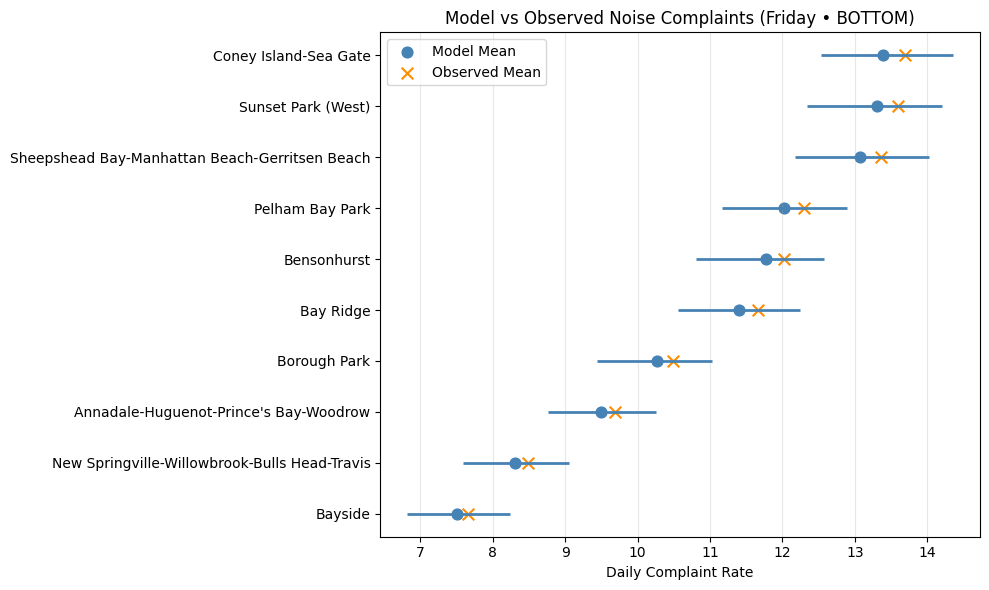

In [23]:
_ = plot_puma_model_vs_observed(cmp, dow="Friday", segment="bottom", n=10, figsize=(10, 6))

#### Mid

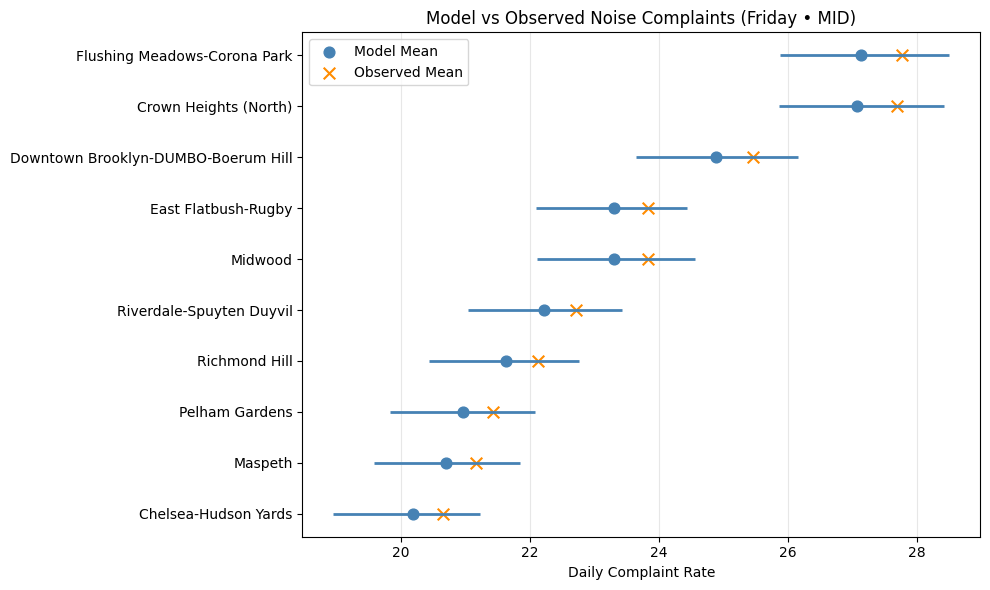

In [24]:
_ = plot_puma_model_vs_observed(cmp, dow="Friday", segment="mid", n=10, figsize=(10, 6))

#### Bottom

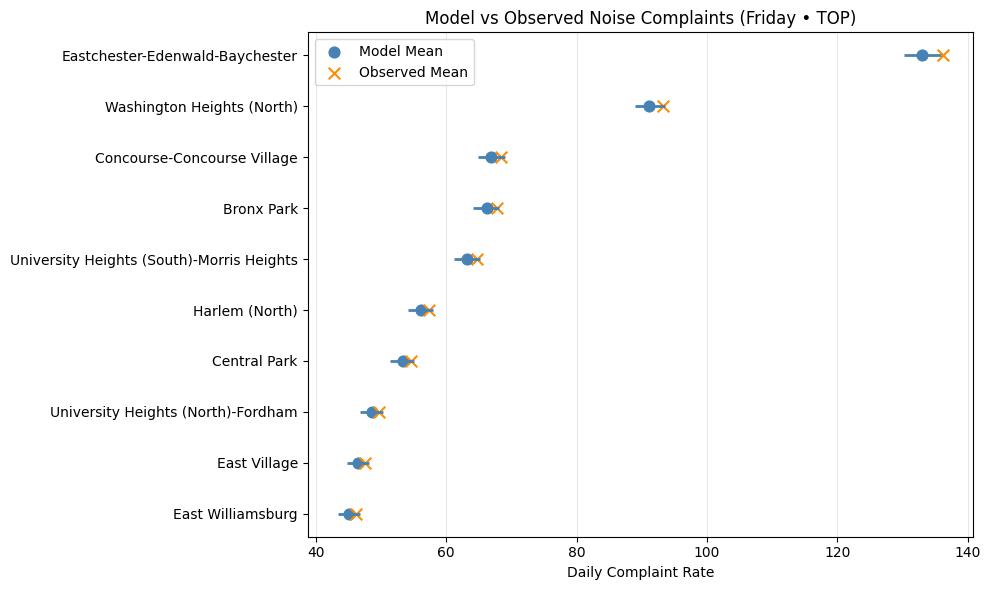

In [25]:
_ = plot_puma_model_vs_observed(cmp, dow="Friday", segment="top", n=10, figsize=(10, 6))

#### We export the model for further use.

In [26]:
export_idata(idata_nta_pois, "../data/processed/models/model2_unpooled_nta_idata.nc")

✅ Saved idata -> ../data/processed/models/model2_unpooled_nta_idata.nc


'../data/processed/models/model2_unpooled_nta_idata.nc'